In [ ]:
import torch
import numpy as np

class Environment:
    def __init__(self, dims=2, bounding_box = None):
        self.dims = dims  # Number of dimensions (2 for 2D, 3 for 3D)
        self.obstacles = []  # List to store obstacles
        self.targets = []  # List to store targets or hoops
        self.bounding_box = bounding_box

    def add_obstacle(self, center, radius):
        self.obstacles.append({"center": torch.tensor(center, dtype=torch.float32).cuda(), "radius": radius})

    def add_target(self, center, radius):
        self.targets.append({"center": torch.tensor(center, dtype=torch.float32).cuda(), "radius": radius})

    def check_bounding_box(self, point):
        if self.bounding_box is not None:
            lower, upper = self.bounding_box
            return torch.any(point < lower) or torch.any(point > upper)
        return torch.tensor(False, dtype=torch.bool)

    def check_collision(self, point):
      for obstacle in self.obstacles:
          if torch.norm(point - obstacle["center"]) < obstacle["radius"]:
              return torch.tensor(True, dtype=torch.bool)
      return torch.tensor(False, dtype=torch.bool)

    def get_first_target_center(self):
        if len(self.targets) > 0:
            return self.targets[0]["center"]
        else:
            raise ValueError("No targets have been added to the environment.")

    def check_target(self, point):
        for target in self.targets:
            if torch.norm(point - target["center"]) < target["radius"]:
                return torch.tensor(True, dtype=torch.bool)
        return torch.tensor(False, dtype=torch.bool)


In [ ]:
import torch
import torch.nn as nn

def sdf_unit_circle(x, y, z):
    return torch.sqrt(x**2 + y**2 + z**2) - 1

class NeuralODEFunc(nn.Module):
    def __init__(self, input_dim):
        super(NeuralODEFunc, self).__init__()
        hidden_dim = 64
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, t, x):


        return self.net(x)


In [ ]:
try:
  from torchdiffeq import odeint
except:
  !pip install torchdiffeq
  from torchdiffeq import odeint

class NeuralODE(nn.Module):
    def __init__(self, input_dim, environment):
        super(NeuralODE, self).__init__()
        self.environment = environment
        self.odefunc = NeuralODEFunc(input_dim)

    def forward(self, t, initial_conditions):
        trajectory = odeint(self.odefunc, initial_conditions, t)
        return trajectory

    def sdf_obstacle(self, point):
        sdf_values = torch.stack([torch.norm(point - obs["center"]) - obs["radius"] for obs in self.environment.obstacles])
        return torch.min(sdf_values)

    def sdf_target(self, point):
        sdf_values = torch.stack([torch.norm(point - target["center"]) - target["radius"] for target in self.environment.targets])
        return torch.min(sdf_values)

    def sdf_bounding_box(self, point):
        if self.environment.bounding_box is not None:
            lower, upper = self.environment.bounding_box
            outside_lower = lower - point
            outside_upper = point - upper
            outside = torch.cat([outside_lower, outside_upper])
            min_distance = torch.min(outside)
            sigmoid_penalty = torch.sigmoid(-10 * min_distance)
            return sigmoid_penalty
        return torch.tensor(0.0, dtype=torch.float32).cuda()

    def loss_function(self, trajectory, target_point):
        final_point = trajectory[-1, 0, :]  # Take the last point of the first trajectory
        distance_to_target = torch.norm(final_point - target_point)
        trajectory = trajectory[:, 0, :]

        sdf_obstacle_values = torch.stack([self.sdf_obstacle(point) for point in trajectory])
        sdf_obstacle_penalty = torch.sigmoid(-10 * sdf_obstacle_values).sum()

        sdf_bounding_box_penalty = torch.stack([self.sdf_bounding_box(point) for point in trajectory]).sum()
        # sdf_bounding_box_penalty = torch.sigmoid(-10 * sdf_bounding_box_values).sum()

        print(f"Final point: {final_point}")
        print(f"Distance to target: {distance_to_target}")
        print(f"SDF obstacle penalty: {sdf_obstacle_penalty}")
        print(f"SDF bounding box penalty: {sdf_bounding_box_penalty}")

        # Weights
        lambda_ = torch.tensor(1.0, dtype=torch.float32).cuda()
        lambda_box = torch.tensor(1.0, dtype=torch.float32).cuda()
        # gamma_ = torch.tensor(1.0, dtype=torch.float32).cuda()

        # sdf_target_reward = torch.sigmoid(-10 * self.sdf_
        # Final loss
        loss = distance_to_target + lambda_ * sdf_obstacle_penalty + lambda_box * sdf_bounding_box_penalty # - gamma_ * sdf_target_reward
        return loss


In [ ]:
try:
  import pytorch_lightning as pl
except:
  !pip install pytorch-lightning
  import pytorch_lightning as pl

class NeuralODELightning(pl.LightningModule):
    def __init__(self, input_dim, environment, target_point):
        super(NeuralODELightning, self).__init__()
        self.model = NeuralODE(input_dim, environment)
        self.target_point = environment.get_first_target_center()

    def forward(self, t, initial_conditions):
        return self.model(t, initial_conditions)

    def training_step(self, batch, batch_idx):
        t, initial_conditions = batch
        trajectory = self(t, initial_conditions)
        loss = self.model.loss_function(trajectory, self.target_point)
        return {"loss": loss}

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)
        return optimizer

In [ ]:
bounding_box = torch.tensor([[0.5, 0.5], [8.0, 8.0]]).cuda()  # Lower left and upper right corners
env = Environment(dims=2, bounding_box = bounding_box)
# env.add_obstacle(center=(2, 2), radius=0.5)
# env.add_obstacle(center=(2,9), radius = 0.5)
# env.add_obstacle(center=(9,2), radius = 0.5)
# env.add_obstacle(center=(3,5), radius = 0.5)
# env.add_obstacle(center=(7,5), radius = 0.5)
# env.add_obstacle(center=(5,3), radius = 0.5)

for i in range(2,8):
    for j in range(2, 8):
        env.add_obstacle(center=(i,j), radius = 0.1)

env.add_target(center=(7.5, 7.5), radius=0.1)


In [ ]:
env.targets

[{'center': tensor([7.5000, 7.5000], device='cuda:0'), 'radius': 0.1}]

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Define DataLoader
initial_conditions = torch.tensor([[1.5, 1.5]], dtype=torch.float32)  # Start from the middle of the grid
time_steps = torch.linspace(0, 1, 100)  # Time steps for ODE solver

# Repeat the initial_conditions tensor to match the size of time_steps
initial_conditions_repeated = initial_conditions.repeat(len(time_steps), 1)

dataset = TensorDataset(time_steps, initial_conditions_repeated)
train_dataloader = DataLoader(dataset, batch_size=100)


# Initialize NeuralODE model
input_dim = 2  # 2D environment
model = NeuralODELightning(input_dim, env, env.targets[0]["center"])


# Initialize PyTorch Lightning Trainer and train the model
trainer = pl.Trainer(max_epochs=600, accelerator="auto")
trainer.fit(model, train_dataloader)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | NeuralODE | 4.5 K 
------------------------------------
4.5 K     Trainable params
0         Non-trainable params
4.5 K     Total params
0.018     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

Final point: tensor([1.3256, 1.4611], device='cuda:0', grad_fn=<SliceBackward0>)
Distance to target: 8.63659954071045
SDF obstacle penalty: 0.11741607636213303
SDF bounding box penalty: 100.0
Final point: tensor([1.3830, 1.5196], device='cuda:0', grad_fn=<SliceBackward0>)
Distance to target: 8.554695129394531
SDF obstacle penalty: 0.16428545117378235
SDF bounding box penalty: 100.0
Final point: tensor([1.4331, 1.5773], device='cuda:0', grad_fn=<SliceBackward0>)
Distance to target: 8.478484153747559
SDF obstacle penalty: 0.23440121114253998
SDF bounding box penalty: 100.0
Final point: tensor([1.4528, 1.6216], device='cuda:0', grad_fn=<SliceBackward0>)
Distance to target: 8.433528900146484
SDF obstacle penalty: 0.292250394821167
SDF bounding box penalty: 100.0
Final point: tensor([1.4336, 1.6331], device='cuda:0', grad_fn=<SliceBackward0>)
Distance to target: 8.439288139343262
SDF obstacle penalty: 0.279813677072525
SDF bounding box penalty: 100.0
Final point: tensor([1.4013, 1.6328], de

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=600` reached.


In [ ]:

# Initialize PyTorch Lightning Trainer and train the model
trainer = pl.Trainer(max_epochs=20, accelerator="auto")
trainer.fit(model, train_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | NeuralODE | 4.5 K 
------------------------------------
4.5 K     Trainable params
0         Non-trainable params
4.5 K     Total params
0.018     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

Final point: tensor([6.4010, 9.4567], device='cuda:0', grad_fn=<SliceBackward0>)
Distance to target: 2.2442517280578613
SDF obstacle penalty: 0.09852231293916702
SDF bounding box penalty: 100.0
Final point: tensor([7.4466, 9.0452], device='cuda:0', grad_fn=<SliceBackward0>)
Distance to target: 1.5460983514785767
SDF obstacle penalty: 1.1861286163330078
SDF bounding box penalty: 100.0
Final point: tensor([8.1152, 8.6090], device='cuda:0', grad_fn=<SliceBackward0>)
Distance to target: 1.2682220935821533
SDF obstacle penalty: 1.829883098602295
SDF bounding box penalty: 100.0
Final point: tensor([7.8931, 8.3784], device='cuda:0', grad_fn=<SliceBackward0>)
Distance to target: 0.9623634219169617
SDF obstacle penalty: 2.286405563354492
SDF bounding box penalty: 100.0
Final point: tensor([7.3160, 8.4017], device='cuda:0', grad_fn=<SliceBackward0>)
Distance to target: 0.9202738404273987
SDF obstacle penalty: 1.6697659492492676
SDF bounding box penalty: 100.0
Final point: tensor([6.7612, 8.3804]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


/usr/local/lib/python3.10/dist-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


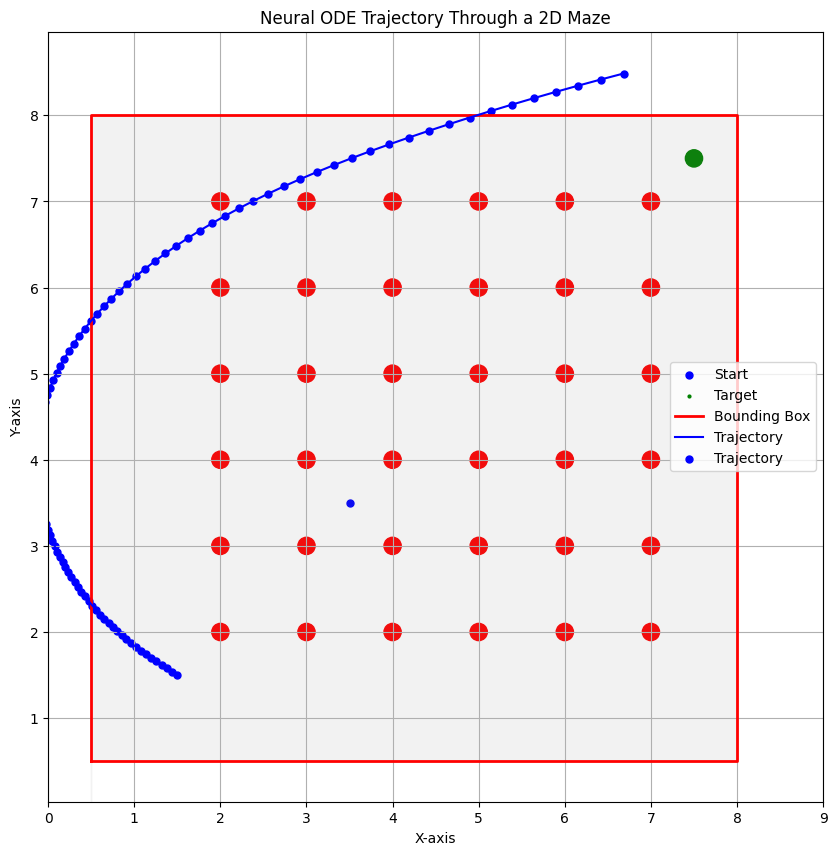

In [ ]:
import matplotlib.pyplot as plt

# Define fine-grained time points for evaluation
time_points = torch.linspace(0, 1, 100).cuda()

# Run the trained model to obtain the trajectory
with torch.no_grad():
    trajectory = model(time_points, initial_conditions_repeated[0:1]).cpu().numpy()

# Plot the environment grid, obstacles, and targets
plt.figure(figsize=(10, 10))
for obstacle in env.obstacles:
    circle = plt.Circle(obstacle["center"], obstacle["radius"], color='r')
    plt.gca().add_patch(circle)
for target in env.targets:
    circle = plt.Circle(target["center"], target["radius"], color='g')
    plt.gca().add_patch(circle)

# plot the bounding box

lower_left = np.array([0.5, 0.5])
upper_right = np.array([8, 8])

plt.scatter(3.5, 3.5, s = 25, label='Start', color='b')
plt.scatter(7.5, 7.5, s = 4, label='Target', color='g')
# Points for the bounding box lines
x_values = [lower_left[0], upper_right[0], upper_right[0], lower_left[0], lower_left[0]]
y_values = [lower_left[1], lower_left[1], upper_right[1], upper_right[1], lower_left[1]]

plt.plot(x_values, y_values, 'r-', linewidth=2, label='Bounding Box')
plt.fill_between(x_values, y_values, color='grey', alpha=0.1)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Bounding Box')
plt.axis('equal')
#
# Here's a visualization of the bounding box, outlined in red. The shaded area inside the box represents the region where the trajectory should ideally be contained. You can integrate such a bounding box into your environment and adapt your loss function to keep the trajectory within this region. Would you like to proceed with that?






# Plot the trajectory
plt.plot(trajectory[:, 0, 0], trajectory[:, 0, 1], label='Trajectory', color='b')
plt.scatter(trajectory[:, 0, 0], trajectory[:, 0, 1], s=25, label='Trajectory', color='b')

# Additional plot settings
plt.xlim(0, 9)
plt.ylim(0, 9)
plt.legend()
plt.title('Neural ODE Trajectory Through a 2D Maze')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(True)
plt.show()
